# Phase 5: Evaluation & Required Course Visuals
## Blood Cancer Detection — Hybrid Dataset

All metrics and visuals use the **held-out test set (316 rows, original imbalanced distribution)**. The SMOTE-balanced training data is never used here.

Required course visuals produced:
1. Confusion matrix heatmap
2. True-vs-predicted distribution bar chart
3. Treemap — true label frequencies
4. Treemap — predicted label frequencies
5. One-vs-rest ROC curves (per class)
6. Model comparison F1 bar chart (all 5 models on test set)

> **Synthetic-data caveat:** 12 of 15 numeric features are synthetic (see `docs/cbc_reference_ranges.md`). Metrics reflect pipeline methodology; the high scores are expected given the synthetic feature construction. See the caveat cell in `03_modeling.ipynb` for a full explanation.

In [1]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.express as px
import plotly.io as pio
from pathlib import Path

from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, accuracy_score, precision_score, recall_score,
    roc_curve, auc,
)
from sklearn.preprocessing import label_binarize

PROJECT = Path('..')
MODELS  = PROJECT / 'models'
REPORTS = PROJECT / 'reports'
OUT     = PROJECT / 'outputs' / 'evaluation'
OUT.mkdir(parents=True, exist_ok=True)

sns.set_theme(style='whitegrid')
plt.rcParams.update({'figure.dpi': 120, 'savefig.bbox': 'tight'})

X_test     = np.load(MODELS / 'X_test.npy')
y_test     = np.load(MODELS / 'y_test.npy')
le         = joblib.load(MODELS / 'label_encoder.pkl')
best_model = joblib.load(MODELS / 'best_model.pkl')
best_name  = joblib.load(MODELS / 'best_model_name.pkl')
all_models = joblib.load(MODELS / 'all_models.pkl')

CLASSES = list(le.classes_)
PALETTE = dict(zip(CLASSES, sns.color_palette('Set2', len(CLASSES))))

y_pred      = best_model.predict(X_test)
y_pred_lbl  = le.inverse_transform(y_pred)
y_test_lbl  = le.inverse_transform(y_test)

print(f'Best model  : {best_name}')
print(f'Test rows   : {len(y_test)}')
print(f'Test classes: {CLASSES}')


Best model  : Random Forest
Test rows   : 316
Test classes: ['ALL', 'AML', 'CLL', 'CML', 'Lymphoma', 'Multiple Myeloma', 'Normal']


### Metrics Report (best model on test set)

In [2]:
report_dict = classification_report(
    y_test_lbl, y_pred_lbl, target_names=CLASSES,
    output_dict=True, zero_division=0,
)

# Per-class sensitivity & specificity from confusion matrix
cm = confusion_matrix(y_test_lbl, y_pred_lbl, labels=CLASSES)
sens_spec = {}
for i, cls in enumerate(CLASSES):
    tp = cm[i, i]
    fp = cm[:, i].sum() - tp
    fn = cm[i, :].sum() - tp
    tn = cm.sum() - tp - fp - fn
    sens_spec[cls] = {
        'sensitivity': tp / (tp + fn) if (tp + fn) > 0 else 0.0,
        'specificity': tn / (tn + fp) if (tn + fp) > 0 else 0.0,
    }

rep_path = REPORTS / 'phase5_evaluation_summary.txt'
with open(rep_path, 'w', encoding='utf-8') as f:
    f.write('=== PHASE 5: EVALUATION SUMMARY ===\n')
    f.write(f'Model      : {best_name}\n')
    f.write(f'Test rows  : {len(y_test)}  (original imbalanced distribution)\n\n')
    f.write('--- OVERALL METRICS ---\n')
    f.write(f'Accuracy          : {accuracy_score(y_test_lbl, y_pred_lbl):.4f}\n')
    f.write(f'F1 Macro          : {f1_score(y_test_lbl, y_pred_lbl, average="macro", zero_division=0):.4f}\n')
    f.write(f'Precision Macro   : {precision_score(y_test_lbl, y_pred_lbl, average="macro", zero_division=0):.4f}\n')
    f.write(f'Recall Macro      : {recall_score(y_test_lbl, y_pred_lbl, average="macro", zero_division=0):.4f}\n\n')
    f.write('--- PER-CLASS REPORT ---\n')
    f.write(classification_report(y_test_lbl, y_pred_lbl, target_names=CLASSES, zero_division=0))
    f.write('\n--- PER-CLASS SENSITIVITY & SPECIFICITY ---\n')
    f.write(f'{"Class":<20} {"Sensitivity":>12} {"Specificity":>12}\n')
    f.write('-' * 46 + '\n')
    for cls, vals in sens_spec.items():
        f.write(f'{cls:<20} {vals["sensitivity"]:>12.4f} {vals["specificity"]:>12.4f}\n')

print(f'Metrics -> {rep_path}')
print(classification_report(y_test_lbl, y_pred_lbl, target_names=CLASSES, zero_division=0))


Metrics -> ..\reports\phase5_evaluation_summary.txt
                  precision    recall  f1-score   support

             ALL       1.00      1.00      1.00        28
             AML       1.00      1.00      1.00        25
             CLL       1.00      1.00      1.00        28
             CML       0.96      0.96      0.96        24
        Lymphoma       0.96      1.00      0.98        23
Multiple Myeloma       0.96      0.92      0.94        26
          Normal       1.00      1.00      1.00       162

        accuracy                           0.99       316
       macro avg       0.98      0.98      0.98       316
    weighted avg       0.99      0.99      0.99       316



### Chart 1 — Confusion Matrix Heatmap

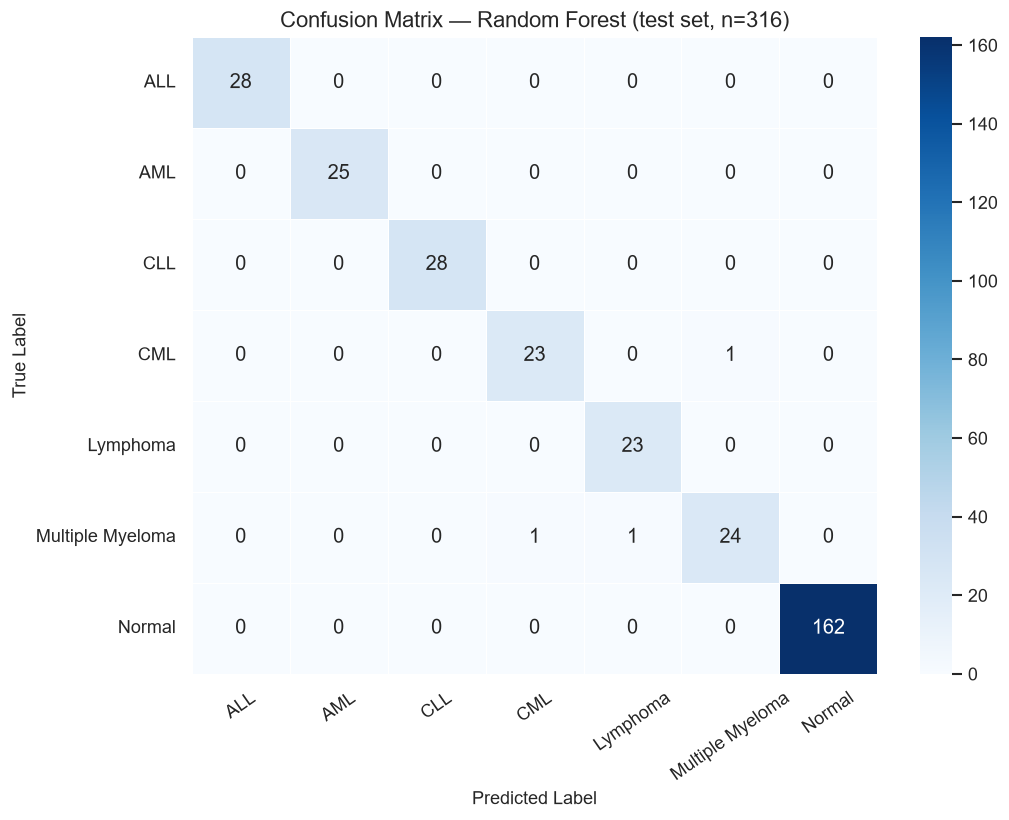

Saved: outputs/evaluation/01_confusion_matrix.png


In [3]:
fig, ax = plt.subplots(figsize=(9, 7))
cm_display = confusion_matrix(y_test_lbl, y_pred_lbl, labels=CLASSES)
sns.heatmap(
    cm_display, annot=True, fmt='d', cmap='Blues',
    xticklabels=CLASSES, yticklabels=CLASSES,
    linewidths=0.5, ax=ax,
)
ax.set_title(f'Confusion Matrix — {best_name} (test set, n=316)', fontsize=13)
ax.set_xlabel('Predicted Label', fontsize=11)
ax.set_ylabel('True Label', fontsize=11)
ax.tick_params(axis='x', rotation=35)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
fig.savefig(OUT / '01_confusion_matrix.png')
plt.show()
print('Saved: outputs/evaluation/01_confusion_matrix.png')


### Chart 2 — True vs Predicted Distribution

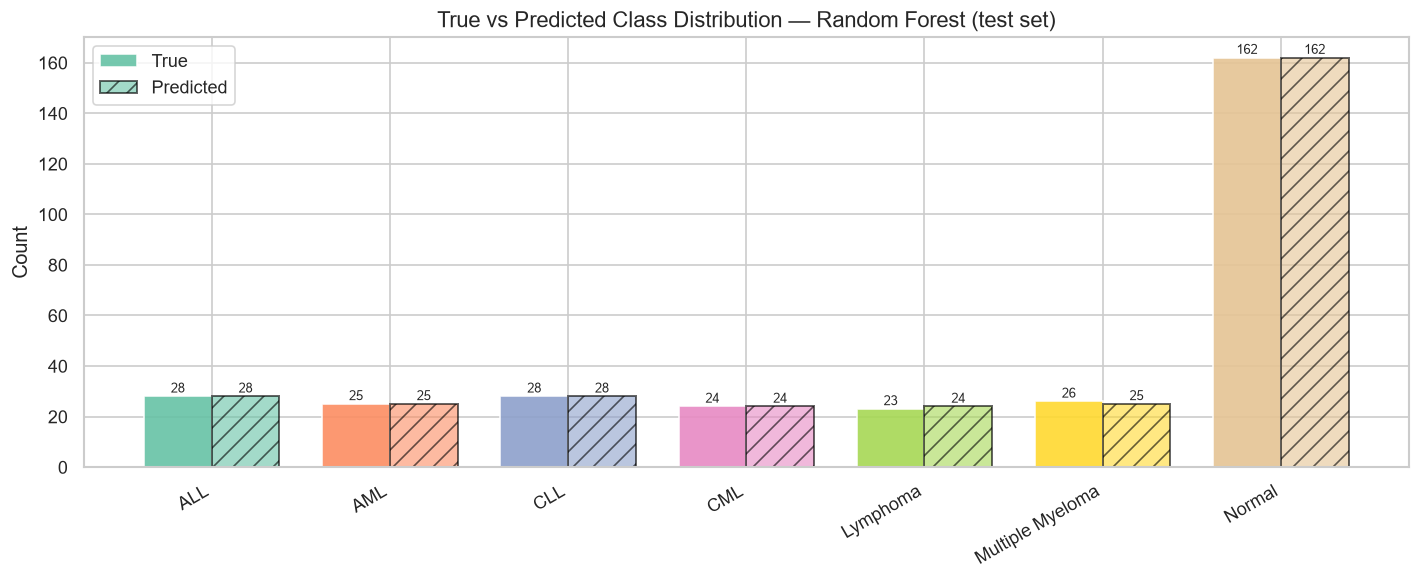

Saved: outputs/evaluation/02_true_vs_predicted.png


In [4]:
true_counts = pd.Series(y_test_lbl).value_counts().reindex(CLASSES, fill_value=0)
pred_counts = pd.Series(y_pred_lbl).value_counts().reindex(CLASSES, fill_value=0)

x     = np.arange(len(CLASSES))
width = 0.38

fig, ax = plt.subplots(figsize=(12, 5))
bars1 = ax.bar(x - width/2, true_counts.values, width, label='True',
               color=[PALETTE[c] for c in CLASSES], edgecolor='white', alpha=0.9)
bars2 = ax.bar(x + width/2, pred_counts.values, width, label='Predicted',
               color=[PALETTE[c] for c in CLASSES], edgecolor='black',
               linewidth=1.2, alpha=0.6, hatch='//')

for bar in list(bars1) + list(bars2):
    h = bar.get_height()
    if h > 0:
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.4,
                str(int(h)), ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(CLASSES, rotation=30, ha='right')
ax.set_ylabel('Count')
ax.set_title(f'True vs Predicted Class Distribution — {best_name} (test set)', fontsize=13)
ax.legend()
plt.tight_layout()
fig.savefig(OUT / '02_true_vs_predicted.png')
plt.show()
print('Saved: outputs/evaluation/02_true_vs_predicted.png')


### Charts 3 & 4 — Treemaps of True and Predicted Label Frequencies

Saved as PNG (kaleido) and HTML fallback.

In [5]:
def save_plotly(fig, stem):
    html_path = OUT / f'{stem}.html'
    fig.write_html(str(html_path))
    try:
        fig.write_image(str(OUT / f'{stem}.png'), width=900, height=550, scale=2)
        print(f'Saved: outputs/evaluation/{stem}.png')
    except Exception as e:
        print(f'PNG export skipped ({e}); HTML saved: outputs/evaluation/{stem}.html')

# Treemap — true
df_true = pd.DataFrame({'label': CLASSES, 'count': true_counts.values})
fig_true = px.treemap(
    df_true, path=['label'], values='count',
    color='label', color_discrete_map=PALETTE,
    title=f'True Label Frequencies (test set, n=316)',
)
fig_true.update_traces(textinfo='label+value+percent root')
fig_true.update_layout(margin=dict(t=50, l=10, r=10, b=10))
save_plotly(fig_true, '03_treemap_true')
fig_true.show()

# Treemap — predicted
df_pred = pd.DataFrame({'label': CLASSES, 'count': pred_counts.values})
fig_pred = px.treemap(
    df_pred, path=['label'], values='count',
    color='label', color_discrete_map=PALETTE,
    title=f'Predicted Label Frequencies — {best_name} (test set, n=316)',
)
fig_pred.update_traces(textinfo='label+value+percent root')
fig_pred.update_layout(margin=dict(t=50, l=10, r=10, b=10))
save_plotly(fig_pred, '04_treemap_predicted')
fig_pred.show()


Saved: outputs/evaluation/03_treemap_true.png


Saved: outputs/evaluation/04_treemap_predicted.png


### Chart 5 — One-vs-Rest ROC Curves (best model, test set)

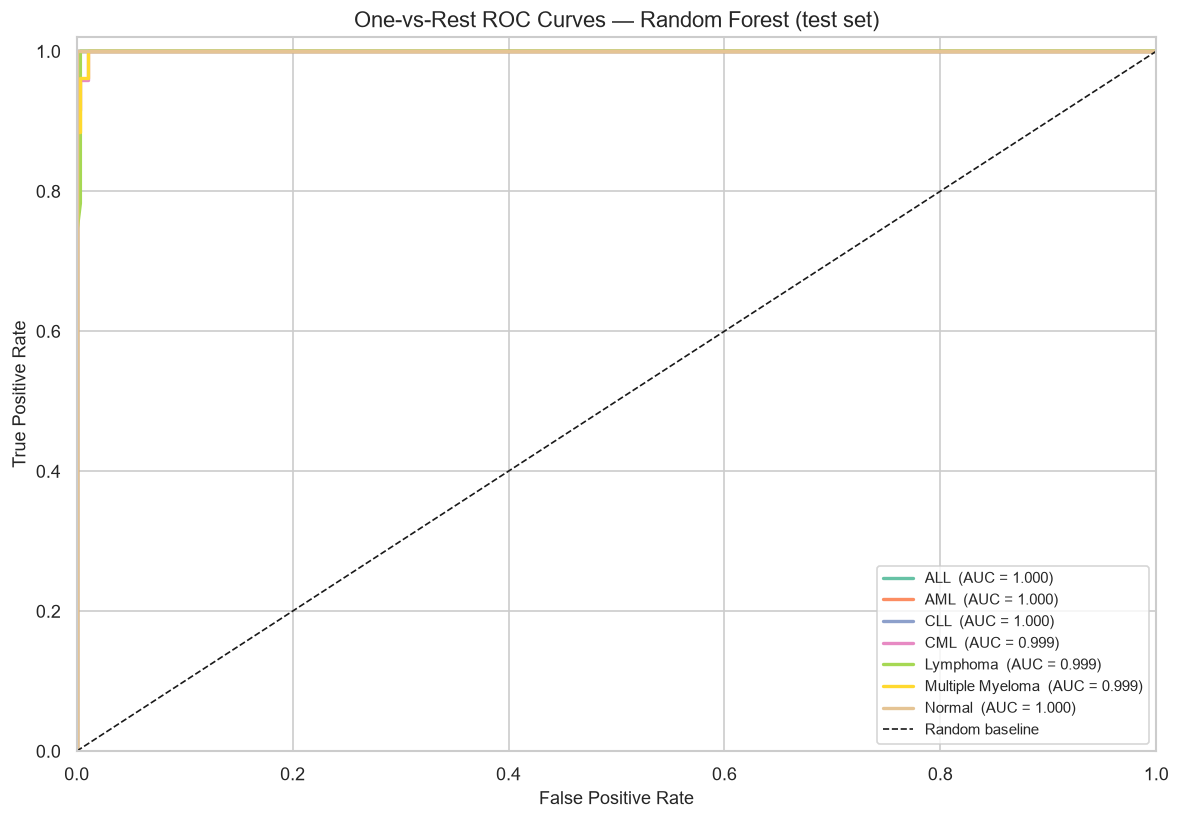

Saved: outputs/evaluation/05_roc_curves.png


In [6]:
y_test_bin = label_binarize(y_test, classes=list(range(len(CLASSES))))
y_prob     = best_model.predict_proba(X_test)

fig, ax = plt.subplots(figsize=(10, 7))
for i, cls in enumerate(CLASSES):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, lw=2, color=list(PALETTE.values())[i],
            label=f'{cls}  (AUC = {roc_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random baseline')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.02])
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title(f'One-vs-Rest ROC Curves — {best_name} (test set)', fontsize=13)
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
fig.savefig(OUT / '05_roc_curves.png')
plt.show()
print('Saved: outputs/evaluation/05_roc_curves.png')


### Chart 6 — Model Comparison F1 Bar Chart (test set)

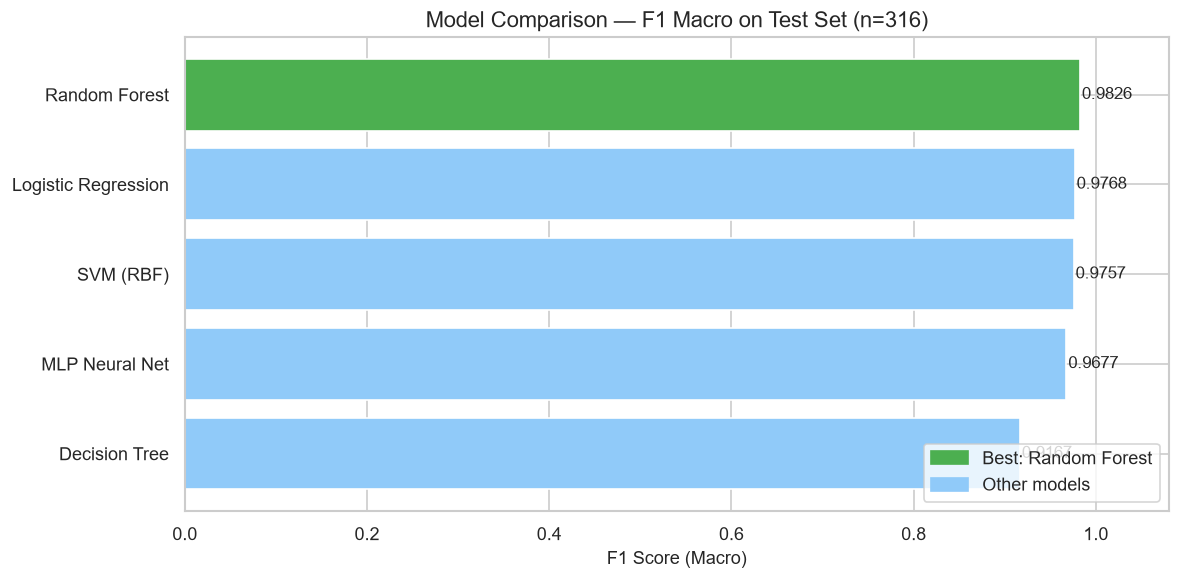

Saved: outputs/evaluation/06_model_comparison_f1.png
Model comparison appended to report.


In [7]:
model_metrics = {}
for name, clf in all_models.items():
    preds = clf.predict(X_test)
    preds_lbl = le.inverse_transform(preds)
    model_metrics[name] = {
        'accuracy':  accuracy_score(y_test_lbl, preds_lbl),
        'f1_macro':  f1_score(y_test_lbl, preds_lbl, average='macro', zero_division=0),
        'f1_weighted': f1_score(y_test_lbl, preds_lbl, average='weighted', zero_division=0),
    }

df_comp = pd.DataFrame(model_metrics).T.sort_values('f1_macro', ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#4CAF50' if n == best_name else '#90CAF9' for n in df_comp.index]
bars = ax.barh(df_comp.index, df_comp['f1_macro'], color=colors, edgecolor='white')
for bar, val in zip(bars, df_comp['f1_macro']):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=10)
ax.set_xlim(0, 1.08)
ax.set_xlabel('F1 Score (Macro)', fontsize=11)
ax.set_title('Model Comparison — F1 Macro on Test Set (n=316)', fontsize=13)
best_patch  = mpatches.Patch(color='#4CAF50', label=f'Best: {best_name}')
other_patch = mpatches.Patch(color='#90CAF9', label='Other models')
ax.legend(handles=[best_patch, other_patch], loc='lower right')
plt.tight_layout()
fig.savefig(OUT / '06_model_comparison_f1.png')
plt.show()
print('Saved: outputs/evaluation/06_model_comparison_f1.png')

# Append model comparison to report
with open(rep_path, 'a', encoding='utf-8') as f:
    f.write('\n--- MODEL COMPARISON ON TEST SET ---\n')
    f.write(f'{"Model":<22} {"Accuracy":>10} {"F1 Macro":>10} {"F1 Weighted":>12}\n')
    f.write('-' * 56 + '\n')
    for name, m in sorted(model_metrics.items(), key=lambda x: -x[1]["f1_macro"]):
        marker = ' <-- best' if name == best_name else ''
        f.write(f'{name:<22} {m["accuracy"]:>10.4f} {m["f1_macro"]:>10.4f} {m["f1_weighted"]:>12.4f}{marker}\n')
print('Model comparison appended to report.')


## Phase 5 Summary

| Visual | File |
|---|---|
| Confusion matrix heatmap | `outputs/evaluation/01_confusion_matrix.png` |
| True vs predicted distribution | `outputs/evaluation/02_true_vs_predicted.png` |
| Treemap — true frequencies | `outputs/evaluation/03_treemap_true.png / .html` |
| Treemap — predicted frequencies | `outputs/evaluation/04_treemap_predicted.png / .html` |
| One-vs-rest ROC curves | `outputs/evaluation/05_roc_curves.png` |
| Model comparison F1 bar chart | `outputs/evaluation/06_model_comparison_f1.png` |

Full metrics (accuracy, precision, recall, F1, sensitivity, specificity per class) in `reports/phase5_evaluation_summary.txt`.

> **Reminder for the report:** All metrics above are on the held-out test set (316 rows, original imbalanced distribution). SMOTE was never applied to this set.

## Limitations & Data Provenance

**Data source.** The base dataset is real: patient records from the Mendeley Bangladesh blood cancer dataset (CC BY 4.0). Class labels (Normal, ALL, AML, CLL, CML, Lymphoma, Multiple Myeloma) are derived from the real `Diagnosis_Result` and `Cancer_Type` fields. Only confirmed diagnoses and ruled-out cases were used; 715 "Suspected" rows were dropped to avoid noisy labels.

**Synthetic features.** The 12 CBC differential columns (RBC, Hemoglobin, Hematocrit, MCV, MCH, MCHC, Neutrophils, Lymphocytes, Monocytes, Eosinophils, Basophils, Blasts) are synthetic. They were generated by sampling from published clinical reference ranges (*Wintrobe's Clinical Hematology*; *Harrison's Principles of Internal Medicine*; *WHO Classification of Haematopoietic Tumours*, 5th ed.) conditioned on each row's real class label. The real WBC and platelet columns were retained from the Mendeley data.

**What this means for the results.** Because the discriminative CBC features were sampled conditioned on the class label, the models partly recover the generation rules rather than learning independent clinical signal. This explains the near-perfect F1 scores. On the real features alone (WBC, platelets), class separation was minimal. Reported accuracy should therefore be read as a demonstration of the end-to-end pipeline (preprocessing, multi-class modeling, evaluation, Spark scaling) — not as evidence of real-world diagnostic accuracy.

**No data leakage.** SMOTE was applied only to the training fold; the test set retained its original imbalanced distribution (51% Normal, 316 rows). The high scores are not an artifact of train-test contamination.